## Plot the 3pt clustering results for mocks

In [5]:
import os
os.environ["MPICH_GPU_SUPPORT_ENABLED"] = "0"
import sys
import random
import numpy as np
import lsstypes as types
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from astropy.table import Table,join,Column

from cosmoprimo.fiducial import DESI, AbacusSummit
from pypower import setup_logging
setup_logging(level='warning')

sys.path.append('../../')
from helper import REDSHIFT_BIN_GLOBAL, REDSHIFT_BIN_LSS, REDSHIFT_ABACUSHF, NRAN_Y3, TRACER_CUTSKY_INFO
from helper import GET_REDSHIFT_SET
from cat_tools import read_positions_weights, get_measurement_fn, parse_zerr_name
from dv_tools import get_repeats_dv, get_cthr

from fit_tools import load_bins, read_data_from_fn
from plotting_tools import COLOR_OVERALL, TPS_LABELS
%load_ext autoreload
%autoreload 2
%matplotlib inline

BASE_DIR = '/pscratch/sd/s/shengyu/galaxies/catalogs/Y3/AbacusHF-v1'
REPEAT_DIR = '/pscratch/sd/s/shengyu/repeats/DA2/loa-v1'
RESULT_DIR = '../results'
OVERLEAF_DIR = '/global/homes/s/shengyu/Y3/desi_y3_redshift_errors/overleaf/figures'

def zfmt(x):
    return f"{x:.3f}".replace(".", "p")

def tps_to_array(tps, ells):
    if isinstance(tps, dict):
        return np.array([np.asarray(tps[ell]) for ell in ells])
    return np.atleast_2d(tps)

cosmo = DESI()
save_fig = True

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [6]:
def get_error_bars(cov_args, corr):
    tps_fid_all = []
    num = 1000 if cov_args['version'] == 'holi-v3' else 25
    for mock_id in range(num)[:]:
        cov_args.update(mock_id=mock_id, use_jax=True, use_dv=False, z_evol=False)
        fn_fid = get_measurement_fn(**cov_args)
        if not os.path.isfile(fn_fid.format("mesh2_spectrum_poles")): continue
        (s_fid, tps_fid), _ = read_data_from_fn(fn_fid, corr, bin_type='test', verbose=False)
        tps_fid_all.append(tps_fid)
    tps_mean_fid = np.atleast_2d(tps_fid_all).mean(axis=0)
    tps_std_fid = np.atleast_2d(tps_fid_all).std(axis=0, ddof=1)
    error_bar = tps_std_fid
    return error_bar

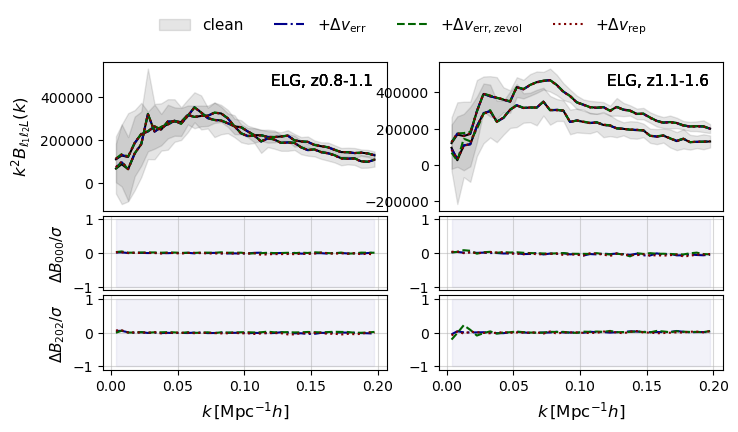

In [7]:
# for three point statistics
from collections import defaultdict

# for two point statistics
corr = 'mesh3_sugiyama' # 
ells=[(0, 0, 0), (2, 0, 2)]
domain = 'altmtl' # cubic, altmtl
version = 'AbacusHF-v2' # AbacusHF-v2, holi-v3
cov_version = 'AbacusHF-v2'
# tracers = ['LRG', 'QSO'][:]
tracers = ['BGS', 'ELG'][1:]
tracer_label = ''.join(t[0] for t in tracers)
zerrs =  ['False','verr_nonparam', 'verr_nonparam_zevol', 'repeat']
labels =  ['clean', r'$+\Delta v_{\rm{err}}$', r'$+\Delta v_{\rm{err, zevol}}$', r'$+\Delta v_{\rm{rep}}$']
# labels = ['clean', '+dv_repeat', '+dv_repeat_zevol', '+dv_err_empirical', '+dv_err_nonparam', '+dv_err_nonparam_zevol']
colors = ['black', 'darkblue', 'darkgreen', 'maroon', 'teal', 'orange']
lss = ['-', '-.', '--', ':']*len(zerrs)
zerr_labels = dict(zip(zerrs, labels))

ZSNAPS, ZRANGES = GET_REDSHIFT_SET(version, domain)
tracer_redshifts = []
for tracer in tracers:
    for zp, zr in zip(ZSNAPS[tracer][:], ZRANGES[tracer][:]):
        tracer_redshifts.append((tracer, zp, zr))
lenz = len(tracer_redshifts)

spow = 2
n_ell = len(ells)
fig = plt.figure(figsize=(lenz * 4, 4))
gs = gridspec.GridSpec(n_ell+1, lenz, wspace=0.18, hspace=0.05, height_ratios=[2]+[1]*n_ell)

for indz, (tracer, zsnap, zrange) in enumerate(tracer_redshifts):    
    data_arges = {'version':version, 'domain':domain, 'tracer':tracer, 'zsnap': zsnap, 'zrange':zrange, "use_dv": False, "z_evol": False}   
    cov_args = {'version': cov_version, 'domain': domain, 'tracer': tracer, 'zsnap': zsnap, 'zrange': zrange, 'use_dv': False, 'z_evol': False}
    error_bar = get_error_bars(cov_args, corr)
    for indv, zerr in enumerate(zerrs):
        tps_all = []
        use_dv, z_evol = parse_zerr_name(zerr)
        for mock_id in range(25)[:]:
            data_arges.update(mock_id=mock_id, use_dv=use_dv, z_evol=z_evol)
            if 'mesh' in corr: data_arges.update(use_jax=True)
            fn = get_measurement_fn(**data_arges)
            if not os.path.isfile(fn.format("mesh3_spectrum_poles_sugiyama")): continue
            (s, tps), _ = read_data_from_fn(fn, corr, bin_type='test')
            tps = tps_to_array(tps, ells)
            tps = np.asarray(tps)
            tps_all.append(tps)
        tps_all = np.array(tps_all)
        tps_mean = tps_all.mean(axis=0)
        tps_std = tps_all.std(axis=0, ddof=1)
        if zerr == 'False':
            tps_mean_fid = tps_mean
            tps_std_fid = tps_std
        ax_top = plt.subplot(gs[indz])
        # ax_top.set_title(f'{tracer}, z{zrange[0]:.1f}-{zrange[1]:.1f}')
        ax_top.text(0.95, 0.92,f'{tracer}, z{zrange[0]:.1f}-{zrange[1]:.1f}',transform=ax_top.transAxes, ha='right', va='top', fontsize=11 )
        ax_top.tick_params(axis="x", which="both", bottom=False, top=False, labelbottom=False)
        for ill, ell in enumerate(ells):
            # plot the mean plots
            ax_top = plt.subplot(gs[indz])
            if zerr == 'False':
                ax_top.plot(s, s**spow*tps_mean[ill], color=colors[indv], ls = '-',  lw = 1.5, zorder=0)
                ax_top.fill_between(s, s**spow*(tps_mean_fid[ill]-error_bar[ill]), s**spow*(tps_mean_fid[ill]+error_bar[ill]), color=colors[indv], alpha=0.1, label=zerr_labels[zerr] if ell == (0,0,0) else None)
                # ax_top.errorbar(s, s**spow*tps_mean[ill], yerr=s**spow*error_bar[ill], fmt='o', linestyle='none', markersize=3, color=colors[indv], alpha=0.5, label=zerr_labels[zerr] if ell == (0,0,0) else None, zorder=0)
            else:
                ax_top.plot(s, s**spow*tps_mean[ill], color=colors[indv], ls = lss[indv],  lw = 1.5, label=zerr_labels[zerr] if ell == (0,0,0) else None, zorder=1)
            if indz == 0:
                ax_top.set_ylabel(TPS_LABELS[corr]['y'], fontsize=12)
            # ax_top.legend(loc=1, fontsize=9)
            # plot the residual plots
            if zerr in ['repeat', 'verr_empirical', 'verr_nonparam', 'verr_nonparam_zevol']:
                if ell == (0,0,0):
                    ax_res = plt.subplot(gs[indz+lenz])
                    if indz == 0: ax_res.set_ylabel(TPS_LABELS[corr]['dy0'], fontsize=11)
                    ax_res.tick_params(axis="x", which="both", bottom=False, top=False, labelbottom=False)
                elif ell == (2,0,2):
                    ax_res = plt.subplot(gs[indz+lenz*2])
                    ax_res.set_xlabel(TPS_LABELS[corr]['x'], fontsize=12)
                    if indz == 0: ax_res.set_ylabel(TPS_LABELS[corr]['dy2'], fontsize=11)
                ax_res.grid(alpha=0.5)
                ax_res.plot(s, (tps_mean[ill]-tps_mean_fid[ill])/error_bar[ill], lw=1.5, ls=lss[indv], color=colors[indv])
                # ax_res.plot(s, (tps_mean[ill]/tps_mean_fid[ill]), lw=1, color=colors[indv])
                if zerr == 'verr_nonparam':
                    ax_res.fill_between(s, -1, 1,  color='darkblue', alpha=0.05)
handles, legend_labels = ax_top.get_legend_handles_labels()
fig.legend(handles, legend_labels, loc='upper center', bbox_to_anchor=(0.5, 1.03), ncol=len(zerrs), fontsize=11, frameon=False)
if save_fig == True and len(tracers) == 2:
    plt.savefig(OVERLEAF_DIR+f'/plot_{corr}_{tracer_label}_clustering.pdf', bbox_inches='tight')
plt.show()

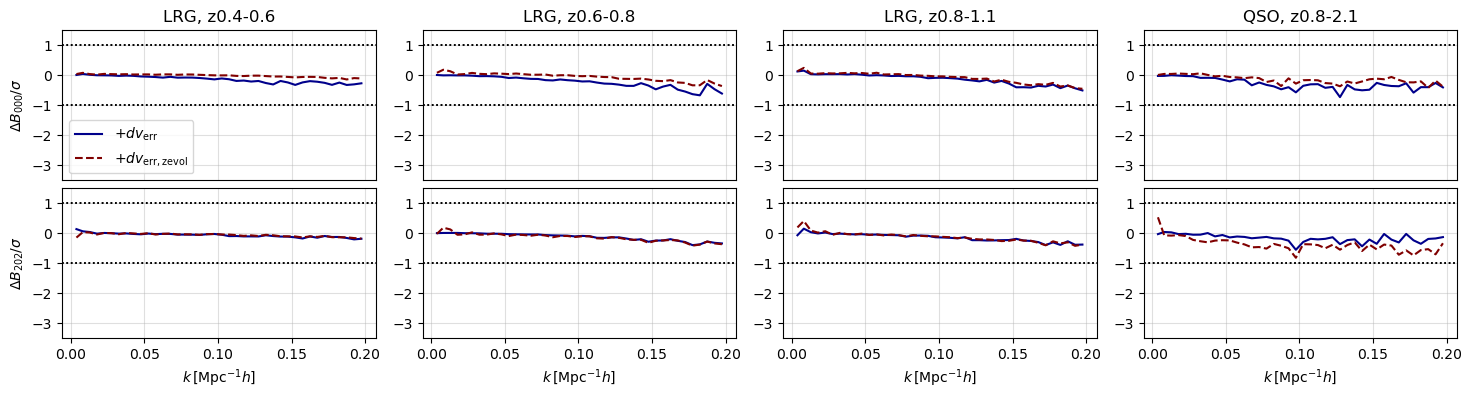

In [36]:
# Residual plots only: (zerr - clean) / sigma_clean for mesh3
corr = 'mesh3_sugiyama'
domain = 'altmtl'
version = 'AbacusHF-v2'
cov_version = 'AbacusHF-v2'
tracers = ['LRG', 'QSO']

zerrs = ['False', 'verr_nonparam', 'verr_nonparam_zevol']

zerr_labels = {
    'False': 'clean',
    'verr_nonparam': r'$+dv_{\rm{err}}$',
    'verr_nonparam_zevol': r'$+dv_{\rm{err,zevol}}$',
}

colors = {
    'verr_nonparam': 'darkblue',
    'verr_nonparam_zevol': 'maroon',
}

lss = {
    'verr_nonparam': '-',
    'verr_nonparam_zevol': '--',
}

ZSNAPS, ZRANGES = GET_REDSHIFT_SET(version, domain)
tracer_redshifts = []
for tracer in tracers:
    for zp, zr in zip(ZSNAPS[tracer][:], ZRANGES[tracer][:]):
        tracer_redshifts.append((tracer, zp, zr))
lenz = len(tracer_redshifts)

ells = [(0, 0, 0), (2, 0, 2)]

n_ell = len(ells)
fig = plt.figure(figsize=(lenz * 4.5, 4))
gs = gridspec.GridSpec(n_ell, lenz, wspace=0.15, hspace=0.05)
for indz, (tracer, zsnap, zrange) in enumerate(tracer_redshifts):
    # Read clean measurements
    clean_all = []
    s_clean = None
    data_args = {'version':version, 'domain':domain, 'tracer':tracer, 'zsnap': zsnap, 'zrange':zrange, "use_dv": False, "z_evol": False}
    cov_args= {'version': cov_version, 'domain': domain, 'tracer': tracer, 'zsnap': zsnap, 'zrange': zrange, 'use_dv': False, 'z_evol': False}
    error_bar = get_error_bars(cov_args, corr)
    for zerr in zerrs:
        tps_all = []
        use_dv, z_evol = parse_zerr_name(zerr)
        for mock_id in range(25):
            data_args.update(mock_id=mock_id, use_dv=use_dv, z_evol=z_evol)
            fn = get_measurement_fn(**data_args)
            (s, tps), _ = read_data_from_fn(fn, corr, bin_type='test')
            tps_all.append(tps_to_array(tps, ells))
        tps_all = np.array(tps_all)
        tps_mean = tps_all.mean(axis=0)
        if zerr == 'False':
            tps_mean_fid = tps_mean
        else: 
            for ill in range(n_ell):
                ax = plt.subplot(gs[ill, indz])
                residual = (tps_mean[ill] - tps_mean_fid[ill]) / error_bar[ill]
                ax.plot(s, residual, color=colors[zerr], ls=lss[zerr], lw=1.5, label=zerr_labels[zerr],)
                ax.axhline(1, color='black', ls=':', lw=1.2)
                ax.axhline(-1, color='black', ls=':', lw=1.2)
                ax.grid(alpha=0.4)
                if corr in ['wplog', 'mpslog']:
                    ax.set_xscale('log')
                if ill == 0:
                    ax.set_title(f'{tracer}, z{zrange[0]:.1f}-{zrange[1]:.1f}')
                    ax.tick_params(axis="x", which="both", bottom=False, labelbottom=False)
                    if indz == 0:
                        ax.set_ylabel(TPS_LABELS[corr]['dy0'])
                else:
                    ax.set_xlabel(TPS_LABELS[corr]['x'])
                    if indz == 0:
                        ax.set_ylabel(TPS_LABELS[corr]['dy2'])
                ax.set_ylim(-3.5, 1.5)
                if ill == 0 and indz == 0:
                    ax.legend(loc=3, fontsize=10)
if save_fig:
    plt.savefig(OVERLEAF_DIR+f'/plot_bk_redshift_evolution_{corr}', dpi=400, bbox_inches='tight')
plt.show()
